# 01. Hybrid Risk Scoring

This notebook combines four complementary wash-trading signals:

- `tabular_score`: wallet feature model
- `motif_score`: graph motif and local-structure model
- `gnn_score`: GraphSAGE message-passing model
- `anomaly_score`: unsupervised anomaly detector

The final layer is a calibrated logistic meta-model trained on the validation split.

Presentation framing:

> Instead of one classifier, we built a multi-signal fraud intelligence system.


In [25]:
from pathlib import Path
import sys

import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "hybrid_models" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from hybrid_models.hybrid_model_utils import (
    plot_evaluation_dashboard,
    plot_hybrid_comparison_bars,
    plot_meta_coefficients,
    plot_signal_correlation,
    run_hybrid_experiment,
    top_hybrid_alerts,
)


In [26]:
FEATURE_GROUP = "features"
ADD_GRAPH_STATS = False
RANDOM_STATE = 42
TABULAR_MODEL_NAME = "xgboost"
MOTIF_MODEL_NAME = "xgboost"
GNN_MODEL_NAME = "graphsage"
GNN_HIDDEN_DIM = 64
GNN_DROPOUT = 0.2
GNN_LEARNING_RATE = 1e-3
GNN_WEIGHT_DECAY = 1e-4
GNN_EPOCHS = 100
GNN_PATIENCE = 15
THRESHOLD_OBJECTIVE = "f1"


,signal,Threshold,PR-AUC,ROC-AUC,F1,Precision,Recall,Specificity,NPV,Balanced-Accuracy,...,Brier-Score,Log-Loss,Accuracy,TP,FP,TN,FN,TopK,Precision@K,Recall@K
4,hybrid_meta,0.900,0.890751,0.970490,0.802508,0.853333,0.757396,0.983471,0.969630,0.870434,...,0.051342,0.179962,0.958000,128,22,1309,41,169,0.798817,0.798817
1,motif,0.925,0.858352,0.969098,0.739437,0.913043,0.621302,0.992487,0.953791,0.806894,...,0.050102,0.164437,0.950667,105,10,1321,64,169,0.745562,0.745562
2,gnn,0.700,0.691773,0.894736,0.647059,0.722628,0.585799,0.971450,0.948643,0.778624,...,0.107441,0.362319,0.928000,99,38,1293,70,169,0.609467,0.609467
0,tabular,0.675,0.521925,0.858431,0.535135,0.492537,0.585799,0.923366,0.946112,0.754582,...,0.125382,0.399566,0.885333,99,102,1229,70,169,0.520710,0.520710
3,anomaly,0.275,0.311030,0.740903,0.333333,0.284519,0.402367,0.871525,0.919905,0.636946,...,0.098428,0.331294,0.818667,68,171,1160,101,169,0.313609,0.313609


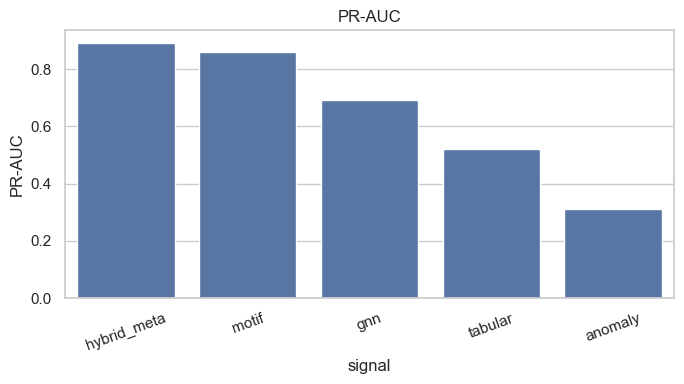

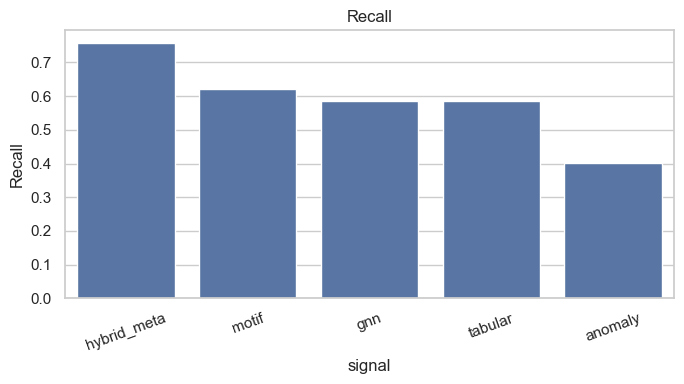

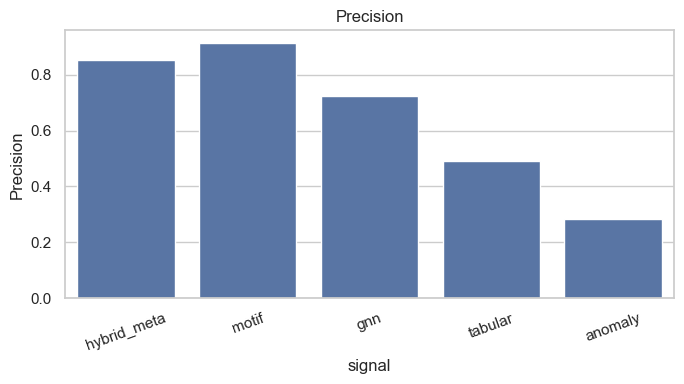

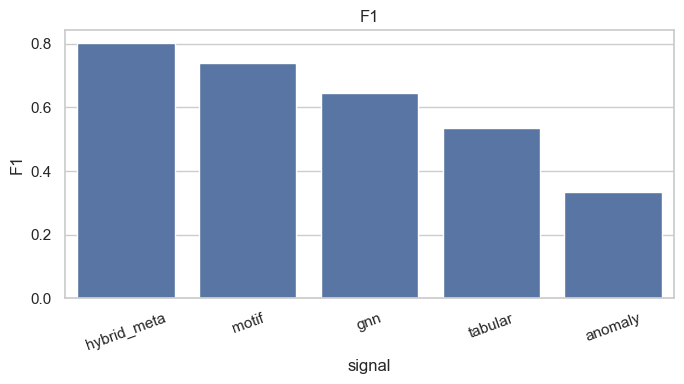

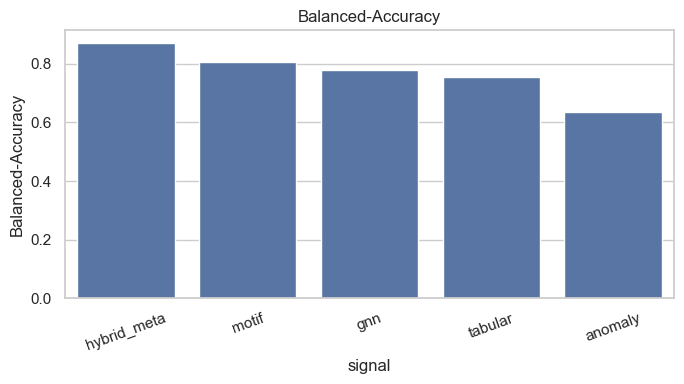

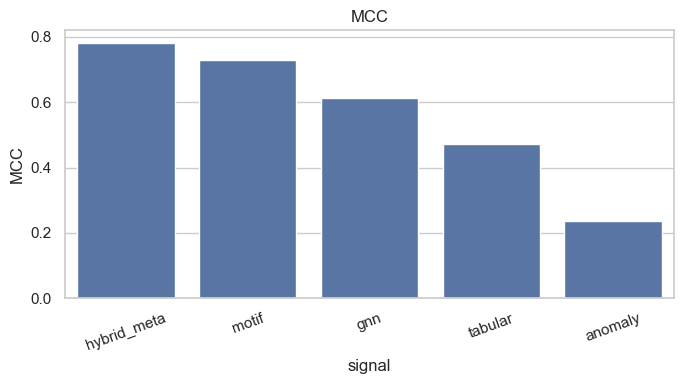

In [27]:
experiment = run_hybrid_experiment(
    feature_group=FEATURE_GROUP,
    add_graph_stats=ADD_GRAPH_STATS,
    random_state=RANDOM_STATE,
    tabular_model_name=TABULAR_MODEL_NAME,
    motif_model_name=MOTIF_MODEL_NAME,
    gnn_model_name=GNN_MODEL_NAME,
    gnn_hidden_dim=GNN_HIDDEN_DIM,
    gnn_dropout=GNN_DROPOUT,
    gnn_learning_rate=GNN_LEARNING_RATE,
    gnn_weight_decay=GNN_WEIGHT_DECAY,
    gnn_epochs=GNN_EPOCHS,
    gnn_patience=GNN_PATIENCE,
    threshold_objective=THRESHOLD_OBJECTIVE,
)

display(experiment["comparison_df"])
plot_hybrid_comparison_bars(experiment["comparison_df"])


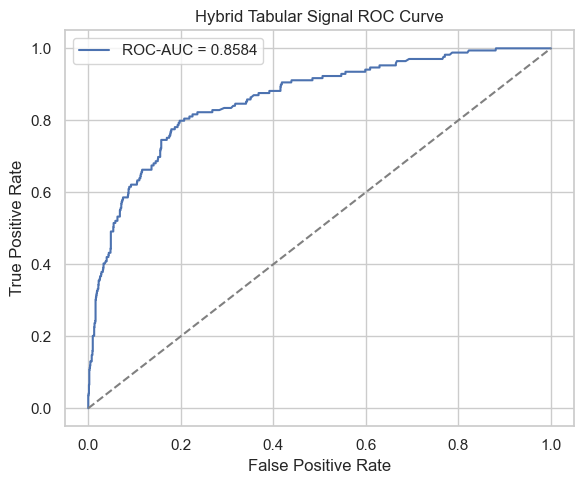

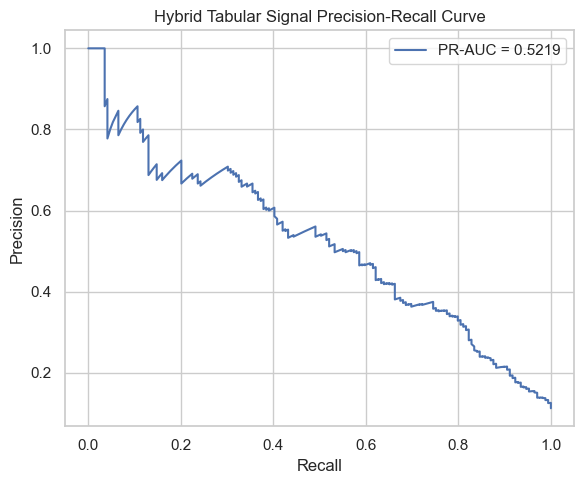

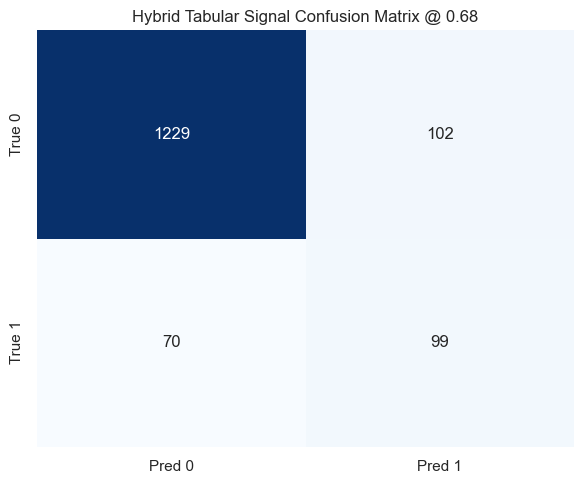

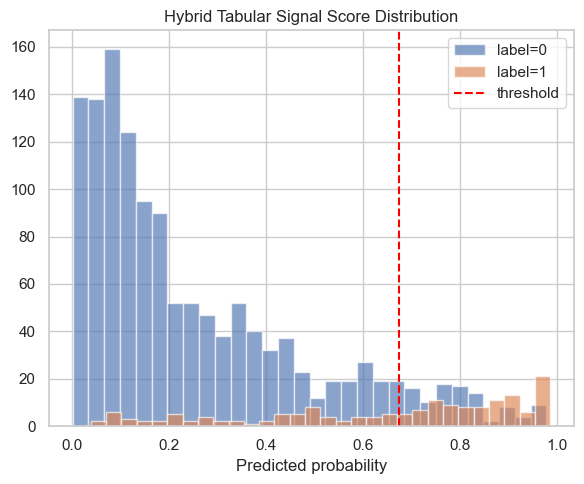

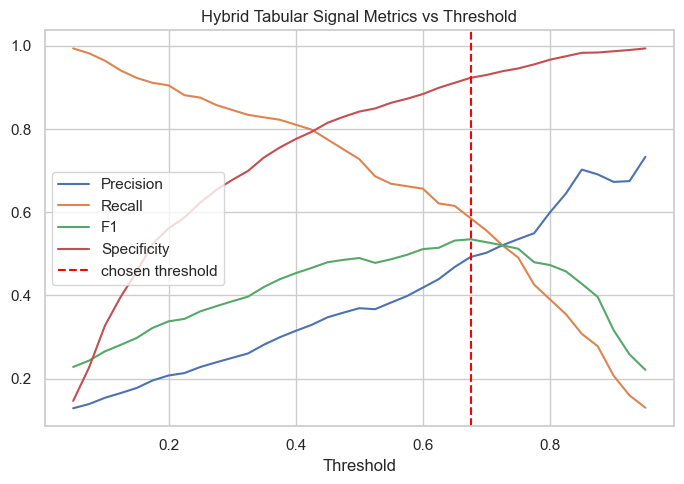

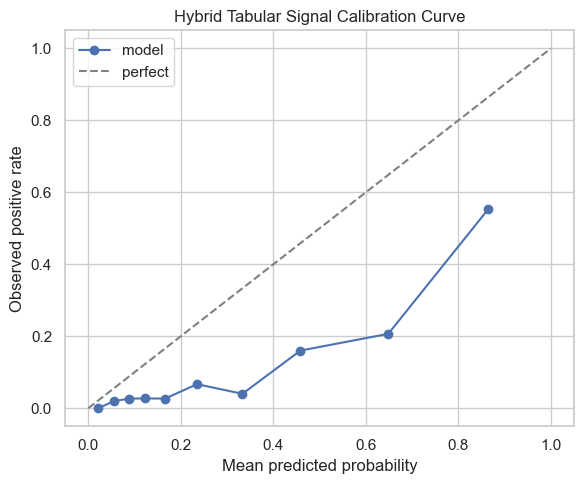

In [28]:
plot_evaluation_dashboard(
    y_true=experiment["test_signal_df"]["label"].to_numpy(),
    y_prob=experiment["test_signal_df"]["tabular_score"].to_numpy(),
    threshold=experiment["tabular_signal"]["threshold"],
    title_prefix="Hybrid Tabular Signal",
)


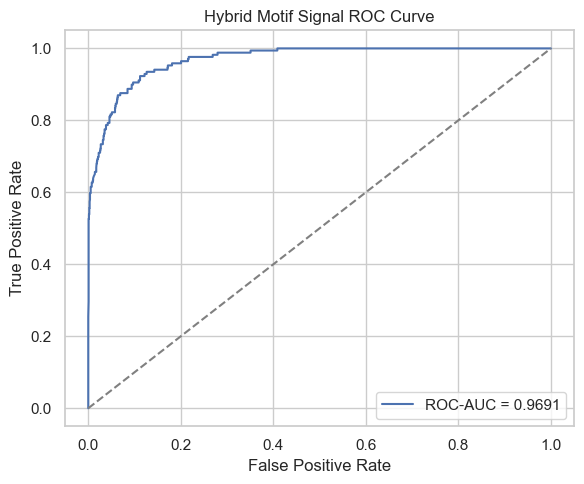

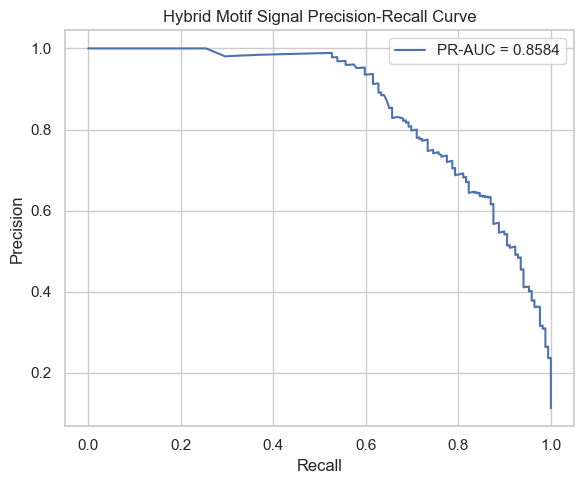

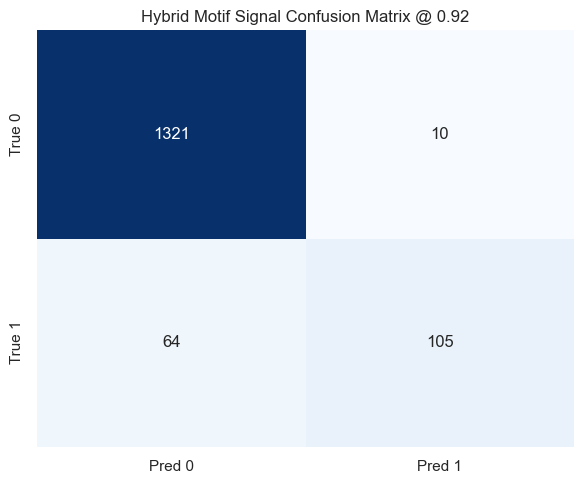

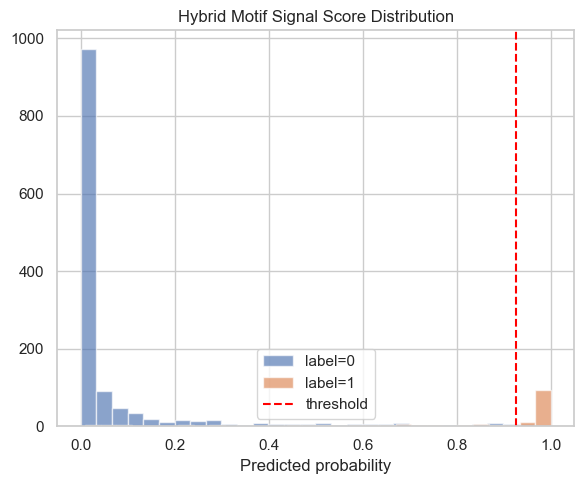

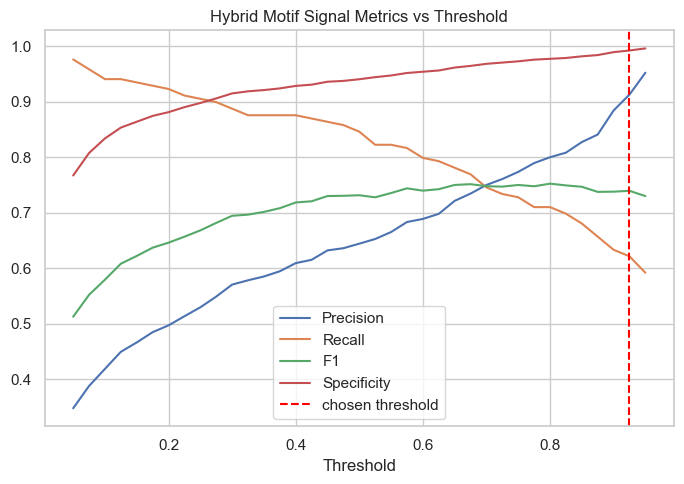

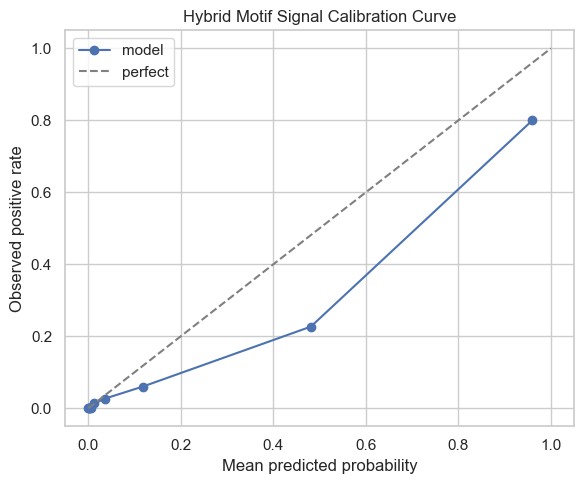

In [29]:
plot_evaluation_dashboard(
    y_true=experiment["test_signal_df"]["label"].to_numpy(),
    y_prob=experiment["test_signal_df"]["motif_score"].to_numpy(),
    threshold=experiment["motif_signal"]["threshold"],
    title_prefix="Hybrid Motif Signal",
)


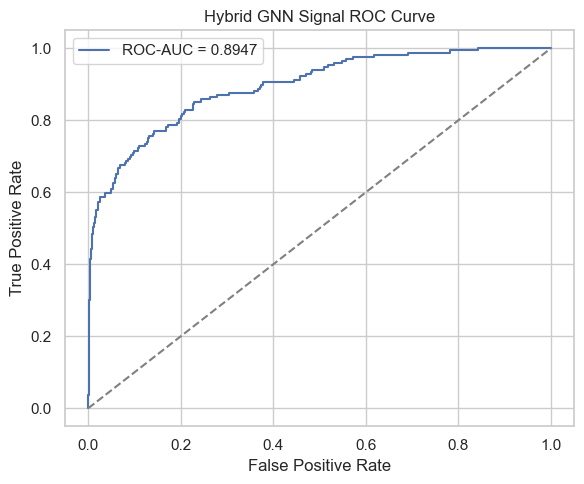

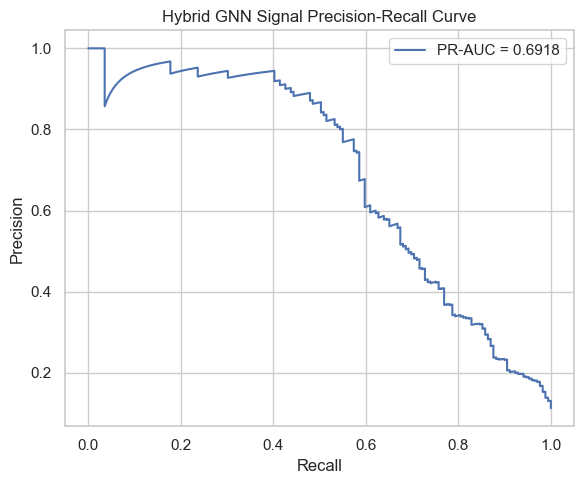

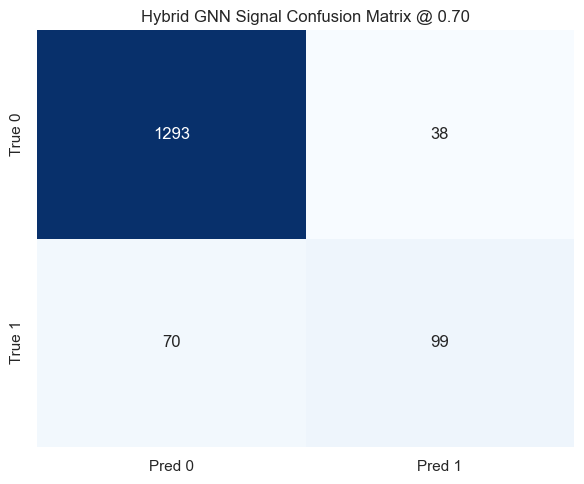

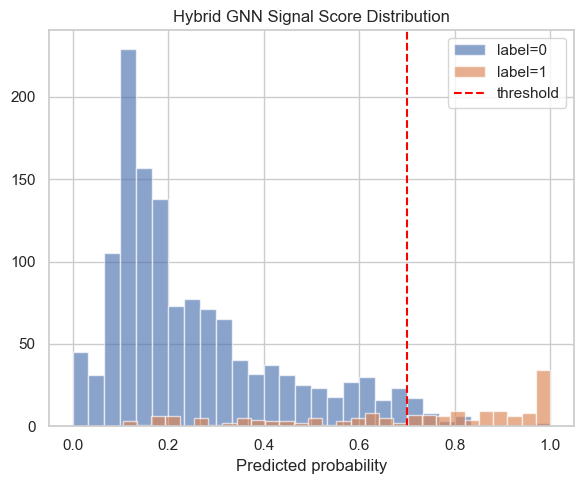

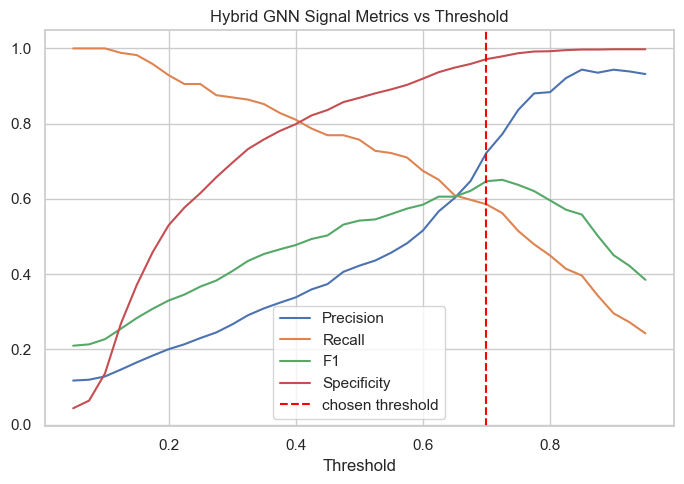

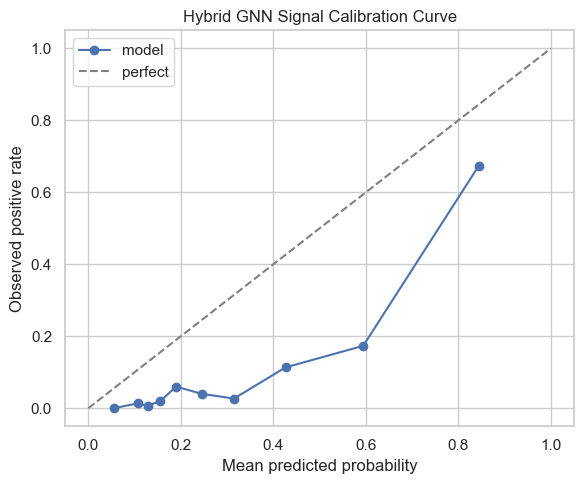

In [30]:
plot_evaluation_dashboard(
    y_true=experiment["test_signal_df"]["label"].to_numpy(),
    y_prob=experiment["test_signal_df"]["gnn_score"].to_numpy(),
    threshold=experiment["gnn_signal"]["threshold"],
    title_prefix="Hybrid GNN Signal",
)


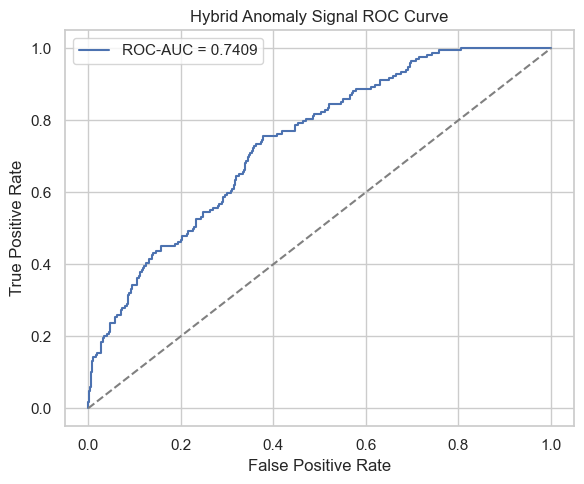

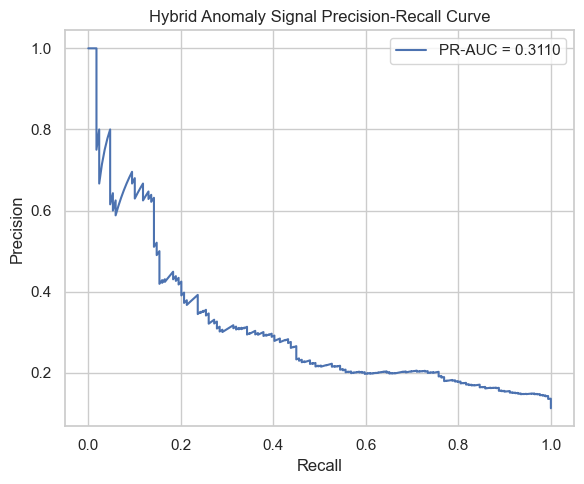

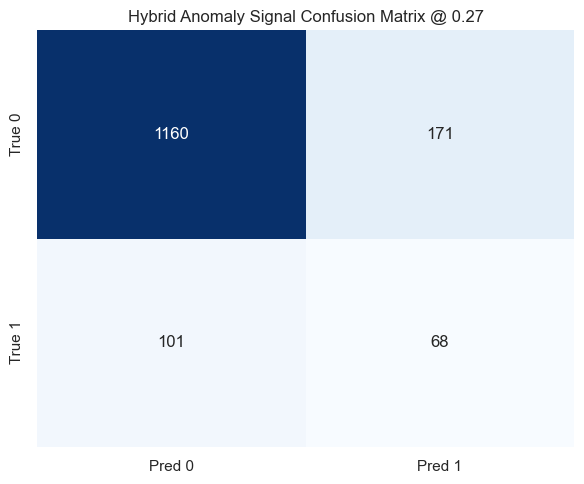

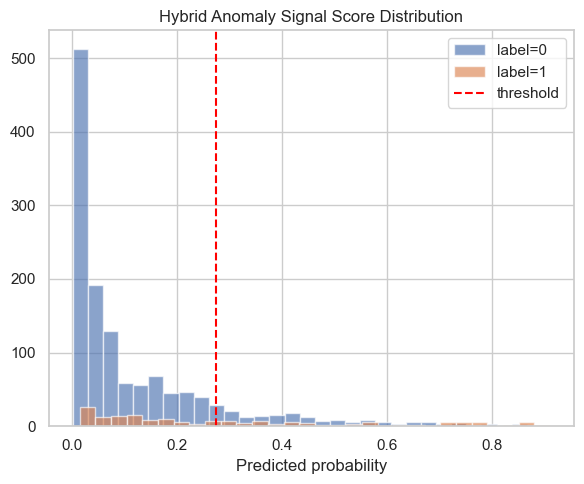

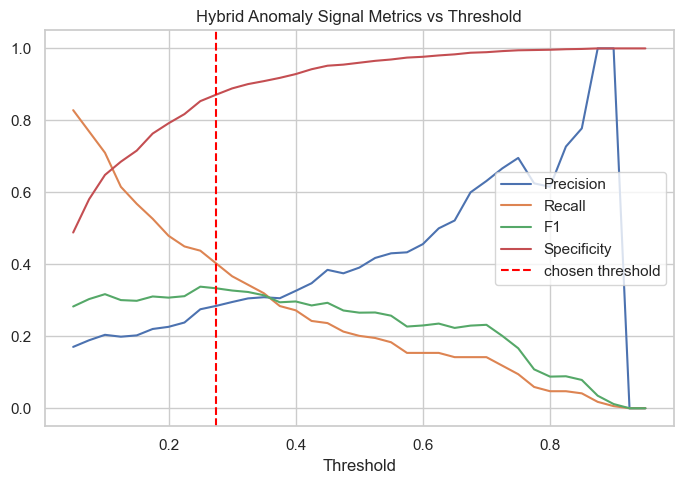

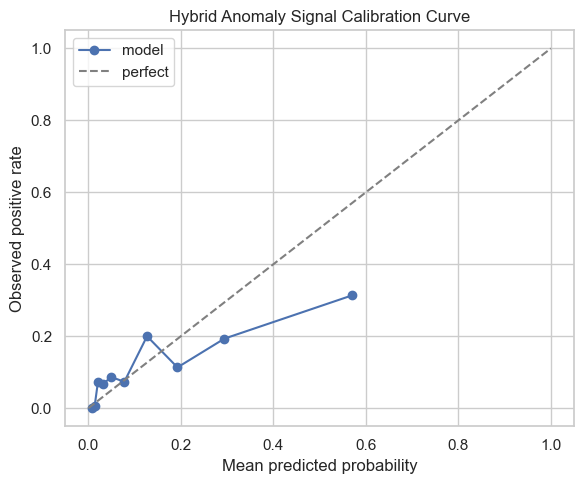

In [31]:
plot_evaluation_dashboard(
    y_true=experiment["test_signal_df"]["label"].to_numpy(),
    y_prob=experiment["test_signal_df"]["anomaly_score"].to_numpy(),
    threshold=experiment["anomaly_signal"]["threshold"],
    title_prefix="Hybrid Anomaly Signal",
)


,signal,coefficient
1,motif_score,1.865915
0,tabular_score,1.118482
2,gnn_score,1.020497
3,anomaly_score,-0.293075


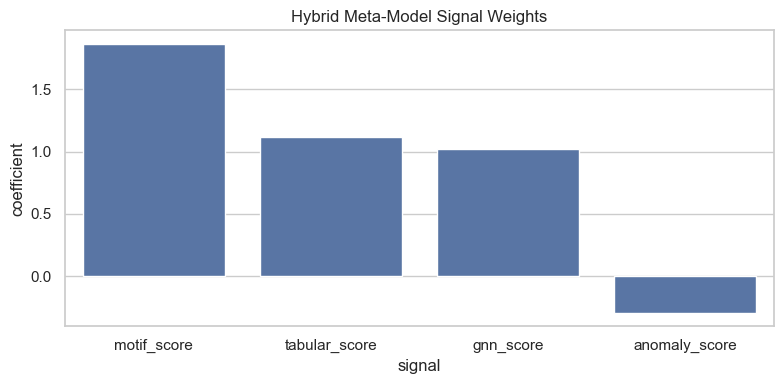

In [32]:
display(experiment["meta_result"]["coefficient_df"])
plot_meta_coefficients(experiment["meta_result"]["coefficient_df"])


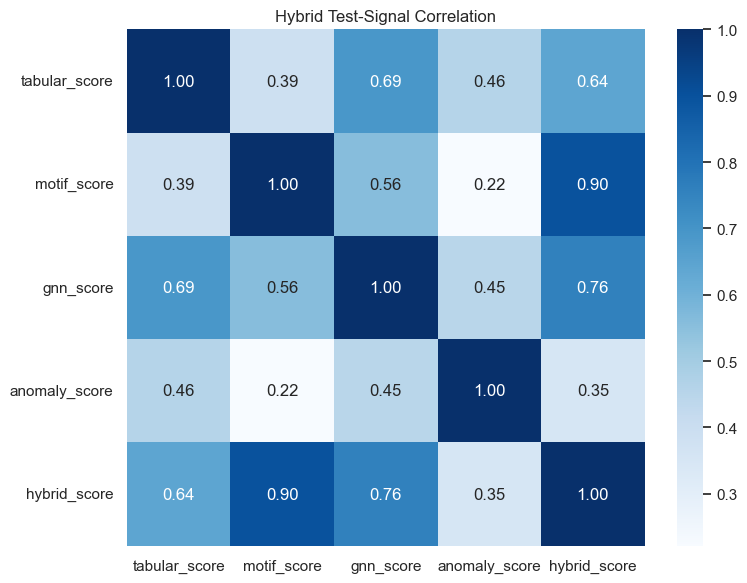

In [33]:
plot_signal_correlation(
    experiment["test_signal_df"],
    title="Hybrid Test-Signal Correlation",
)


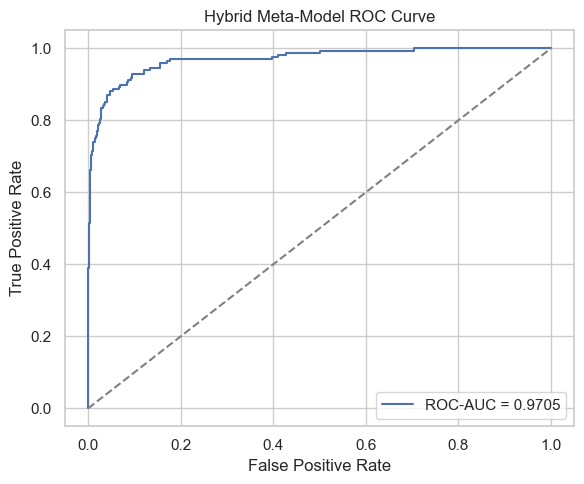

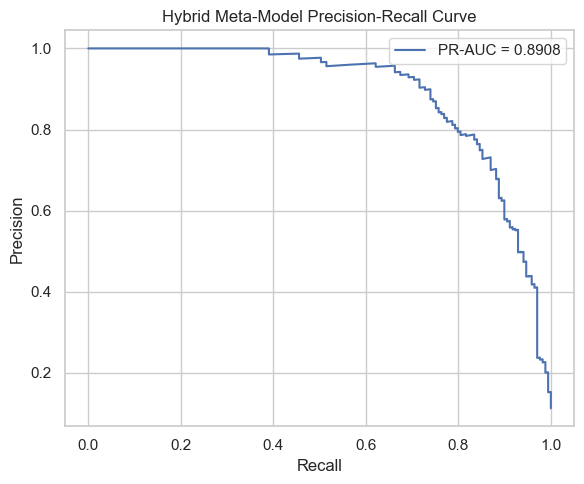

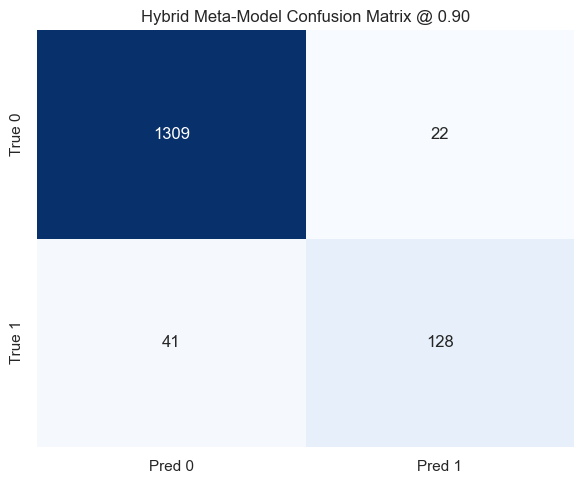

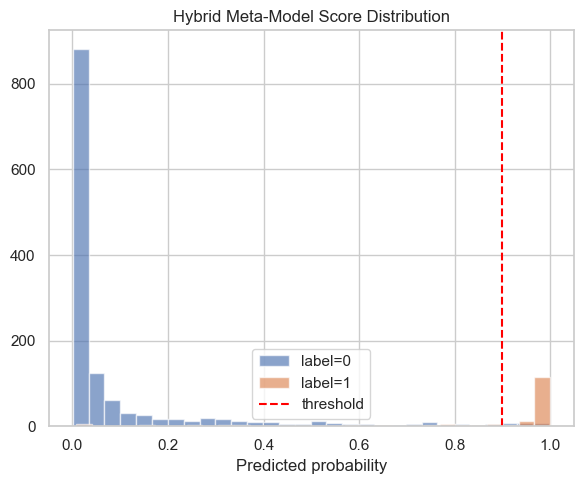

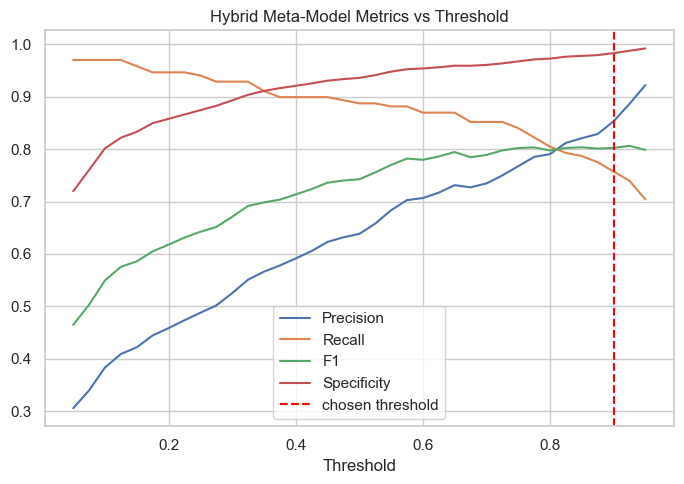

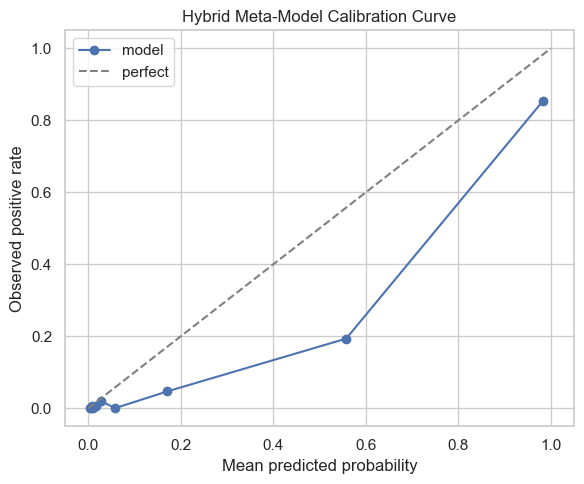

In [34]:
plot_evaluation_dashboard(
    y_true=experiment["test_signal_df"]["label"].to_numpy(),
    y_prob=experiment["meta_result"]["test_prob"],
    threshold=experiment["meta_result"]["threshold"],
    title_prefix="Hybrid Meta-Model",
)


In [35]:
display(top_hybrid_alerts(experiment["test_signal_df"], top_n=25))


,node_id,label,hybrid_score,hybrid_pred,tabular_score,motif_score,gnn_score,anomaly_score
613,1215546,1,0.999646,1,0.977234,0.997937,0.941897,0.088526
865,1190237,1,0.999635,1,0.982906,0.993226,0.920261,0.051974
1261,1266498,1,0.999605,1,0.926099,0.993226,0.978120,0.099393
1199,1225981,1,0.999598,1,0.980701,0.993226,0.897482,0.047593
724,1221954,1,0.999598,1,0.977186,0.995910,0.993689,0.277701
517,1259267,1,0.999562,1,0.981265,0.997458,0.871597,0.050422
869,1182130,1,0.999554,1,0.898456,0.993226,0.971235,0.086789
810,375302,1,0.999550,1,0.940329,0.997537,0.921450,0.086928
588,1181917,1,0.999542,1,0.921115,0.998839,0.968755,0.168618
1010,1233437,1,0.999504,1,0.885482,0.993226,0.998270,0.179775


In [36]:
motif_columns = [column for column in experiment["motif_df"].columns if column.startswith("motif_")]
test_alerts = (
    experiment["test_signal_df"][["node_id", "hybrid_score", "label"]]
    .merge(experiment["motif_df"], on="node_id", how="left")
    .sort_values("hybrid_score", ascending=False)
    .head(15)
)
display(test_alerts[["node_id", "label", "hybrid_score"] + motif_columns[:8]])


,node_id,label,hybrid_score,motif_in_degree,motif_out_degree,motif_total_degree,motif_pagerank,motif_component_size,motif_triangle_count,motif_clustering,motif_reciprocal_partner_count
613,1215546,1,0.999646,1.0,0.0,1.0,0.000030,9763.0,0.0,0.0,0.0
865,1190237,1,0.999635,0.0,1.0,1.0,0.000019,9763.0,0.0,0.0,0.0
1261,1266498,1,0.999605,0.0,1.0,1.0,0.000019,9763.0,0.0,0.0,0.0
1199,1225981,1,0.999598,0.0,1.0,1.0,0.000019,9763.0,0.0,0.0,0.0
724,1221954,1,0.999598,1.0,0.0,1.0,0.000028,3.0,0.0,0.0,0.0
517,1259267,1,0.999562,1.0,0.0,1.0,0.000020,9763.0,0.0,0.0,0.0
869,1182130,1,0.999554,0.0,1.0,1.0,0.000019,9763.0,0.0,0.0,0.0
810,375302,1,0.999550,1.0,0.0,1.0,0.000025,9763.0,0.0,0.0,0.0
588,1181917,1,0.999542,0.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.0
1010,1233437,1,0.999504,0.0,1.0,1.0,0.000019,9763.0,0.0,0.0,0.0


## Readout

If the `hybrid_meta` row wins in `PR-AUC`, `F1`, or `MCC`, you can argue that:

- tabular features capture wallet-level semantics
- motif features capture suspicious local trading structure
- the GNN captures message-passing context
- anomaly detection adds weak-label robustness
- the meta-model learns how to combine them into a final risk score
